# Entrenamiento de Modelos — Dengue País × Semana## Predicción de Brotes de Dengue en El Salvador### Universidad de El Salvador — IngenieríaEntrenamiento y comparación de tres modelos sobre el dataset **país × semana** (2014-2024),con datos de OpenDengue (casos sospechosos nacionales) y clima NASA POWER nacional.**Modelos (de simple a complejo):** 1. Regresión Lineal 2. Random Forest 3. XGBoost**División cronológica (Opción 3):**- Entrenamiento: 2014-2019 (incluye brotes 2014, 2015, 2019)- Validación: 2020-2021 (años tranquilos)- Prueba: 2022-2024 (incluye el brote de 2022)**Ventaja de este dataset:** a diferencia del enfoque departamental anterior, el conjunto deprueba incluye un año epidémico (2022), lo que permite evaluar si el modelo detecta brotes.Se aplica transformación logarítmica al objetivo (mejoró resultados en el proyecto anterior).

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('Librerías cargadas')

Librerías cargadas


## 2. Carga de datos desde GitHub

In [2]:
URL = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/dataset_pais_semana.csv'
df = pd.read_csv(URL)
df = df.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Período: {df.anio_epi.min()}-{df.anio_epi.max()}')
df.head()

Dimensiones: 574 filas x 38 columnas
Período: 2014-2024


,anio_epi,semana_epi,calendar_start_date,calendar_end_date,casos_dengue,t2m_max_sem,t2m_min_sem,t2m_prom_sem,precip_total,precip_dias_lluvia,humedad_prom,viento_prom,amplitud_termica,grados_dia,en_rango_optimo,dist_temp_optima,semana_lluviosa,estacion_lluviosa,semana_sin,semana_cos,t2m_prom_sem_lag1,t2m_prom_sem_lag2,t2m_prom_sem_lag3,t2m_prom_sem_lag4,precip_total_lag1,precip_total_lag2,precip_total_lag3,precip_total_lag4,humedad_prom_lag1,humedad_prom_lag2,humedad_prom_lag3,humedad_prom_lag4,casos_dengue_lag1,casos_dengue_lag2,casos_dengue_lag3,casos_dengue_lag4,casos_tendencia,casos_promedio_4sem
0,2014,1,2013-12-29,2014-01-04,264,31.650104,21.321354,25.898958,0.462083,0.833333,64.026042,2.692917,10.328750,15.898958,1,1.101042,0,0,0.120537,0.992709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,2,2014-01-05,2014-01-11,373,30.761369,20.648929,25.086964,1.235833,2.916667,63.385298,3.557321,10.112440,15.086964,1,1.913036,0,0,0.239316,0.970942,25.898958,NaN,NaN,NaN,0.462083,NaN,NaN,NaN,64.026042,NaN,NaN,NaN,264.0,NaN,NaN,NaN,NaN,264.000000
2,2014,3,2014-01-12,2014-01-18,373,31.106429,19.970298,24.833512,1.143750,2.875000,60.171786,3.780893,11.136131,14.833512,1,2.166488,0,0,0.354605,0.935016,25.086964,25.898958,NaN,NaN,1.235833,0.462083,NaN,NaN,63.385298,64.026042,NaN,NaN,373.0,264.0,NaN,NaN,109.0,318.500000
3,2014,4,2014-01-19,2014-01-25,358,31.781905,20.974940,25.701607,1.421250,2.708333,60.403810,3.939048,10.806964,15.701607,1,1.298393,0,0,0.464723,0.885456,24.833512,25.086964,25.898958,NaN,1.143750,1.235833,0.462083,NaN,60.171786,63.385298,64.026042,NaN,373.0,373.0,264.0,NaN,0.0,336.666667
4,2014,5,2014-01-26,2014-02-01,417,31.978095,21.739167,26.228929,0.382500,1.416667,61.786488,2.180000,10.238929,16.228929,1,0.771071,0,0,0.568065,0.822984,25.701607,24.833512,25.086964,25.898958,1.421250,1.143750,1.235833,0.462083,60.403810,60.171786,63.385298,64.026042,358.0,373.0,373.0,264.0,-15.0,342.000000


## 3. División cronológica (Opción 3)Respetamos el orden temporal para evitar fuga de datos.

In [3]:
train = df[df['anio_epi'].isin([2014,2015,2016,2017,2018,2019])].copy()
val   = df[df['anio_epi'].isin([2020,2021])].copy()
test  = df[df['anio_epi'].isin([2022,2023,2024])].copy()

print(f"Train (2014-2019): {len(train)} filas - casos: {train['casos_dengue'].sum():,}")
print(f"Val   (2020-2021): {len(val)} filas - casos: {val['casos_dengue'].sum():,}")
print(f"Test  (2022-2024): {len(test)} filas - casos: {test['casos_dengue'].sum():,}")

# Verificar orden temporal
print(f"\nVerificación temporal:")
print(f"  Último año train: {train['anio_epi'].max()} < Primer año val: {val['anio_epi'].min()} < Primer año test: {test['anio_epi'].min()}")

Train (2014-2019): 313 filas - casos: 152,633
Val   (2020-2021): 105 filas - casos: 11,202
Test  (2022-2024): 156 filas - casos: 30,882

Verificación temporal:
  Último año train: 2019 < Primer año val: 2020 < Primer año test: 2022


## 4. Selección de variables (evitando fuga de datos)Excluimos identificadores, fechas y la variable objetivo de las predictoras.

In [4]:
OBJETIVO = 'casos_dengue'
excluir = ['casos_dengue', 'anio_epi', 'calendar_start_date',
           'calendar_end_date', 'indice_temporal']
predictoras = [c for c in df.columns if c not in excluir]

print(f'Objetivo: {OBJETIVO}')
print(f'Predictoras ({len(predictoras)}):')
for p in predictoras:
    print(f'  - {p}')

Objetivo: casos_dengue
Predictoras (34):
  - semana_epi
  - t2m_max_sem
  - t2m_min_sem
  - t2m_prom_sem
  - precip_total
  - precip_dias_lluvia
  - humedad_prom
  - viento_prom
  - amplitud_termica
  - grados_dia
  - en_rango_optimo
  - dist_temp_optima
  - semana_lluviosa
  - estacion_lluviosa
  - semana_sin
  - semana_cos
  - t2m_prom_sem_lag1
  - t2m_prom_sem_lag2
  - t2m_prom_sem_lag3
  - t2m_prom_sem_lag4
  - precip_total_lag1
  - precip_total_lag2
  - precip_total_lag3
  - precip_total_lag4
  - humedad_prom_lag1
  - humedad_prom_lag2
  - humedad_prom_lag3
  - humedad_prom_lag4
  - casos_dengue_lag1
  - casos_dengue_lag2
  - casos_dengue_lag3
  - casos_dengue_lag4
  - casos_tendencia
  - casos_promedio_4sem


## 5. Preparar X, y con transformación logarítmica

In [5]:
def preparar(d):
    X = d[predictoras].copy()
    y = d[OBJETIVO].copy()
    return X, y

X_train, y_train_real = preparar(train)
X_val,   y_val_real   = preparar(val)
X_test,  y_test_real  = preparar(test)

# Eliminar nulos de rezagos en train; rellenar en val/test
mask = X_train.notna().all(axis=1)
X_train, y_train_real = X_train[mask], y_train_real[mask]
X_val  = X_val.fillna(0)
X_test = X_test.fillna(0)

# Transformación logarítmica
y_train_log = np.log1p(y_train_real)
y_val_log   = np.log1p(y_val_real)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (309, 34) | X_val: (105, 34) | X_test: (156, 34)


## 6. Función de evaluaciónEvaluamos en casos reales (revirtiendo el log con expm1). Además, calculamos métricaspor año en el conjunto de prueba, para distinguir el desempeño en el año de brote (2022)de los años tranquilos (2023-2024).

In [6]:
def evaluar(y_real, pred_log, nombre):
    pred_real = np.clip(np.expm1(pred_log), 0, None)
    mae = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2 = r2_score(y_real, pred_real)
    print(f'{nombre:22s} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | R2: {r2:6.3f}')
    return {'modelo':nombre,'MAE':mae,'RMSE':rmse,'R2':r2}, pred_real

resultados = []

# Baseline: predecir = semana anterior
baseline_pred = np.clip(test['casos_dengue_lag1'].fillna(0).values, 0, None)
mae_b = mean_absolute_error(y_test_real, baseline_pred)
rmse_b = np.sqrt(mean_squared_error(y_test_real, baseline_pred))
r2_b = r2_score(y_test_real, baseline_pred)
print(f'{"Baseline (lag1)":22s} | MAE: {mae_b:7.2f} | RMSE: {rmse_b:7.2f} | R2: {r2_b:6.3f}')
resultados.append({'modelo':'Baseline (lag1)','MAE':mae_b,'RMSE':rmse_b,'R2':r2_b})

Baseline (lag1)        | MAE:   29.82 | RMSE:   50.86 | R2:  0.875


## 7. Modelo 1 — Regresión Lineal

In [7]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train_log)
pred_lr_log = modelo_lr.predict(X_test)
print('=== REGRESIÓN LINEAL ===')
res_lr, pred_lr = evaluar(y_test_real, pred_lr_log, 'Regresión Lineal')
resultados.append(res_lr)

=== REGRESIÓN LINEAL ===
Regresión Lineal       | MAE:   96.68 | RMSE:  132.38 | R2:  0.150


## 8. Modelo 2 — Random Forest

In [8]:
modelo_rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train_log)
pred_rf_log = modelo_rf.predict(X_test)
print('=== RANDOM FOREST ===')
res_rf, pred_rf = evaluar(y_test_real, pred_rf_log, 'Random Forest')
resultados.append(res_rf)

=== RANDOM FOREST ===
Random Forest          | MAE:   43.46 | RMSE:   59.90 | R2:  0.826


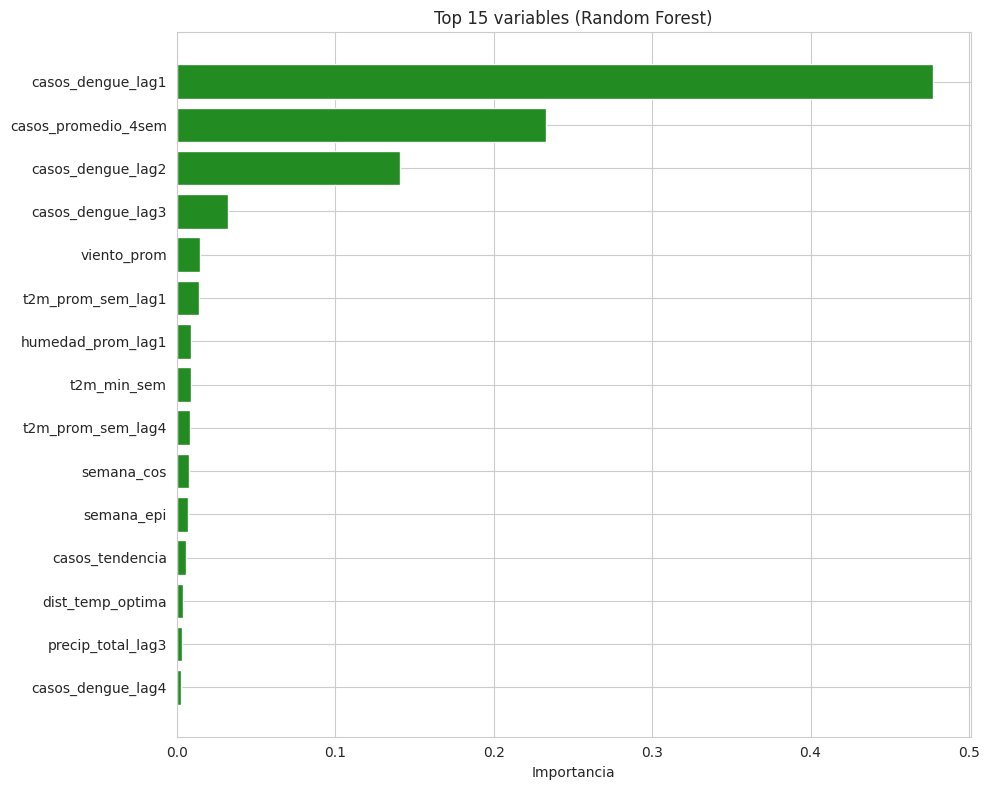

           variable  importancia
  casos_dengue_lag1     0.477204
casos_promedio_4sem     0.232965
  casos_dengue_lag2     0.140849
  casos_dengue_lag3     0.032414
        viento_prom     0.014674
  t2m_prom_sem_lag1     0.013900
  humedad_prom_lag1     0.008808
        t2m_min_sem     0.008740
  t2m_prom_sem_lag4     0.008177
         semana_cos     0.007917


In [9]:
# Importancia de variables
imp_rf = pd.DataFrame({'variable':predictoras,'importancia':modelo_rf.feature_importances_}).sort_values('importancia',ascending=False)
plt.figure(figsize=(10,8))
plt.barh(imp_rf.head(15)['variable'], imp_rf.head(15)['importancia'], color='forestgreen')
plt.xlabel('Importancia'); plt.title('Top 15 variables (Random Forest)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(imp_rf.head(10).to_string(index=False))

## 9. Modelo 3 — XGBoost

In [10]:
modelo_xgb = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
modelo_xgb.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
pred_xgb_log = modelo_xgb.predict(X_test)
print('=== XGBOOST ===')
res_xgb, pred_xgb = evaluar(y_test_real, pred_xgb_log, 'XGBoost')
resultados.append(res_xgb)

=== XGBOOST ===
XGBoost                | MAE:   45.83 | RMSE:   61.81 | R2:  0.815


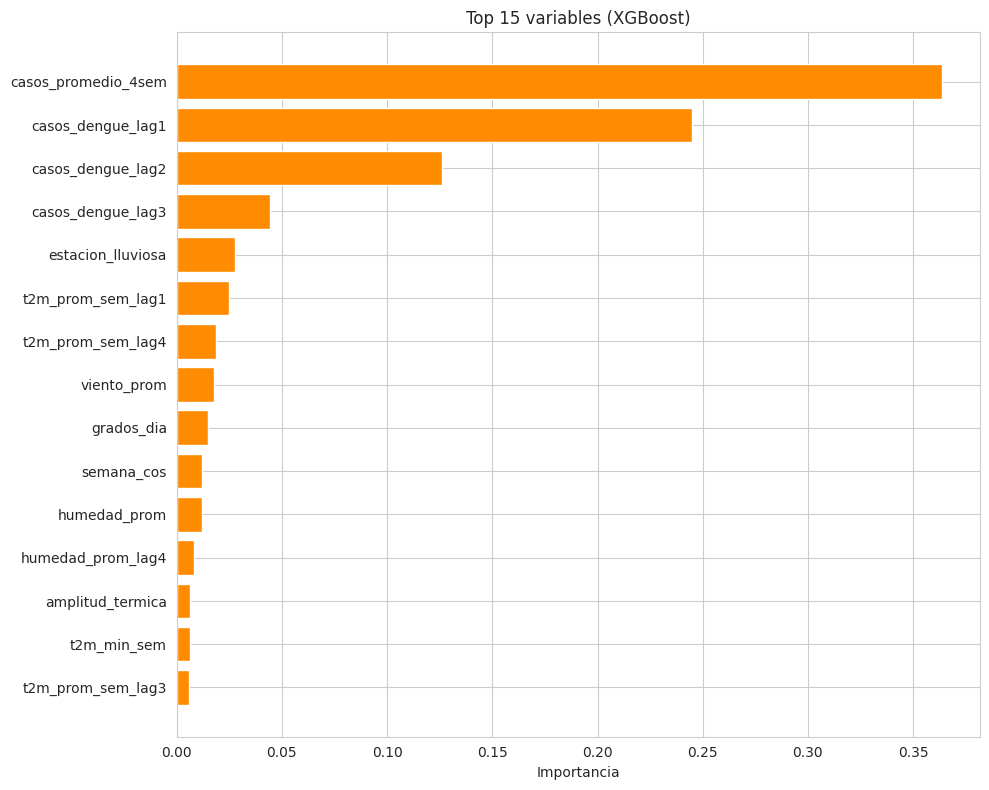

           variable  importancia
casos_promedio_4sem     0.363606
  casos_dengue_lag1     0.244744
  casos_dengue_lag2     0.125887
  casos_dengue_lag3     0.044553
  estacion_lluviosa     0.027654
  t2m_prom_sem_lag1     0.024801
  t2m_prom_sem_lag4     0.018803
        viento_prom     0.017940
         grados_dia     0.015054
         semana_cos     0.011967


In [11]:
imp_xgb = pd.DataFrame({'variable':predictoras,'importancia':modelo_xgb.feature_importances_}).sort_values('importancia',ascending=False)
plt.figure(figsize=(10,8))
plt.barh(imp_xgb.head(15)['variable'], imp_xgb.head(15)['importancia'], color='darkorange')
plt.xlabel('Importancia'); plt.title('Top 15 variables (XGBoost)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(imp_xgb.head(10).to_string(index=False))

## 10. Comparación de modelos

=== COMPARACIÓN (Prueba 2022-2024, en casos reales) ===

          modelo       MAE       RMSE       R2
 Baseline (lag1) 29.820513  50.861804 0.874565
Regresión Lineal 96.683029 132.382024 0.150246
   Random Forest 43.458251  59.898916 0.826031
         XGBoost 45.834988  61.805208 0.814781


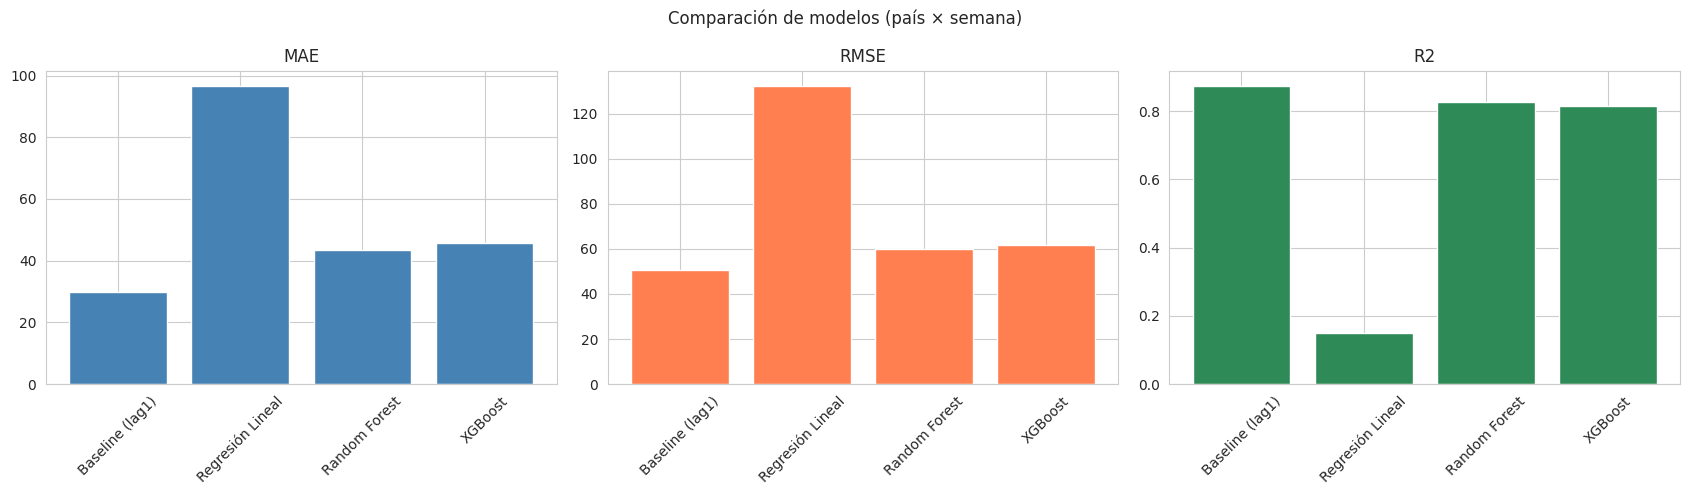

In [12]:
comparacion = pd.DataFrame(resultados)
print('=== COMPARACIÓN (Prueba 2022-2024, en casos reales) ===\n')
print(comparacion.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, met, col in zip(axes, ['MAE','RMSE','R2'], ['steelblue','coral','seagreen']):
    ax.bar(comparacion['modelo'], comparacion[met], color=col)
    ax.set_title(met); ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='black', linewidth=0.5)
plt.suptitle('Comparación de modelos (país × semana)')
plt.tight_layout(); plt.show()

## 11. Desempeño por año (clave para este dataset)Como el conjunto de prueba tiene un año de brote (2022) y dos tranquilos (2023-2024),analizamos el error por año separado para ver si el modelo detecta el brote.

In [13]:
# Usar el mejor modelo (ajustar según resultados)
pred_final = pred_rf  # cambiar a pred_lr o pred_xgb según cuál sea mejor

test_eval = test.copy()
test_eval['prediccion'] = pred_final

print('=== MAE POR AÑO EN LA PRUEBA ===')
for anio in [2022, 2023, 2024]:
    datos = test_eval[test_eval['anio_epi']==anio]
    mae_anio = mean_absolute_error(datos['casos_dengue'], datos['prediccion'])
    print(f'  {anio}: MAE={mae_anio:7.2f} | casos reales totales={datos["casos_dengue"].sum():,} | predichos={datos["prediccion"].sum():,.0f}')

=== MAE POR AÑO EN LA PRUEBA ===
  2022: MAE=  66.71 | casos reales totales=16,542 | predichos=17,707
  2023: MAE=  38.36 | casos reales totales=5,788 | predichos=4,967
  2024: MAE=  25.30 | casos reales totales=8,552 | predichos=7,555


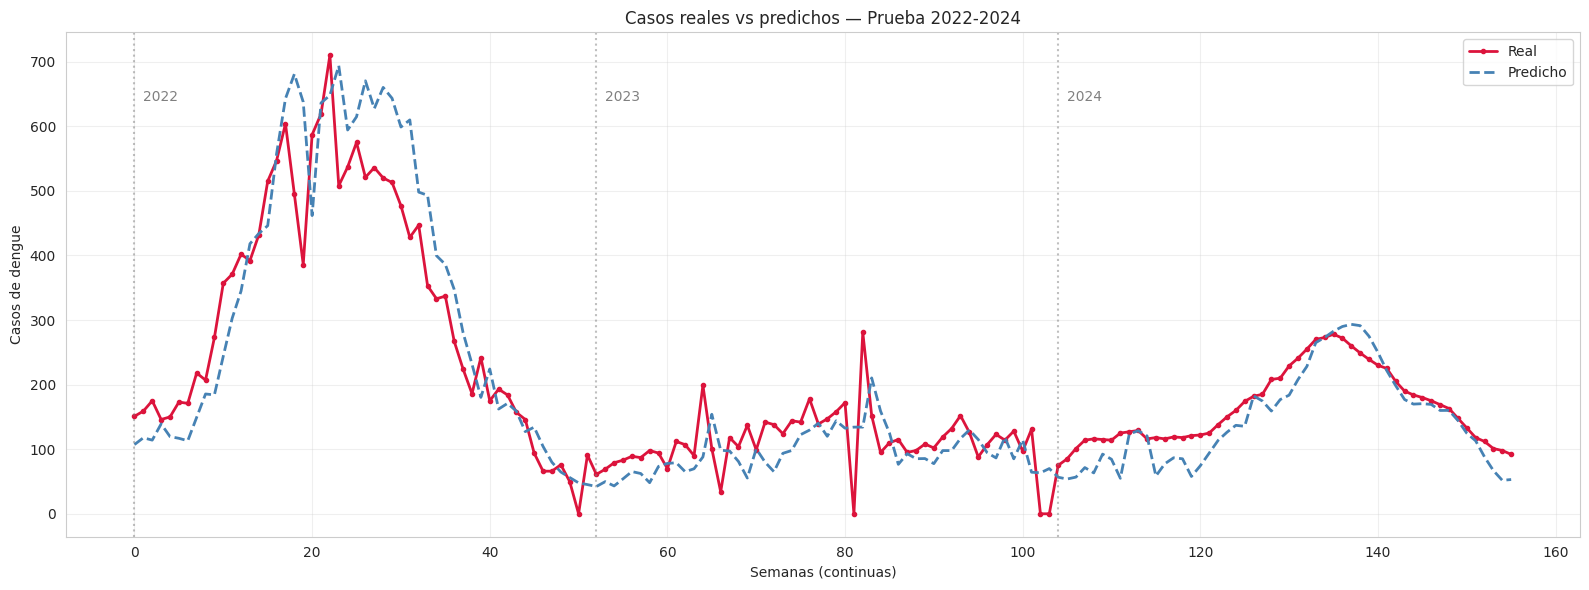

In [14]:
# Gráfica: casos reales vs predichos en la serie de prueba
plt.figure(figsize=(16, 6))
test_eval_sorted = test_eval.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
test_eval_sorted['idx'] = range(len(test_eval_sorted))

plt.plot(test_eval_sorted['idx'], test_eval_sorted['casos_dengue'],
         color='crimson', linewidth=2, marker='o', markersize=3, label='Real')
plt.plot(test_eval_sorted['idx'], test_eval_sorted['prediccion'],
         color='steelblue', linewidth=2, linestyle='--', label='Predicho')

# Marcar años
for anio in [2022, 2023, 2024]:
    idx = test_eval_sorted[test_eval_sorted['anio_epi']==anio]['idx'].min()
    plt.axvline(idx, color='gray', linestyle=':', alpha=0.5)
    plt.text(idx+1, test_eval_sorted['casos_dengue'].max()*0.9, str(anio), color='gray')

plt.title('Casos reales vs predichos — Prueba 2022-2024')
plt.xlabel('Semanas (continuas)'); plt.ylabel('Casos de dengue')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 12. ConclusionesDocumenta con los resultados obtenidos:### Desempeño de los modelos| Modelo | MAE | RMSE | R² | ¿Supera baseline? ||--------|-----|------|-----|-------------------|| Baseline (lag1) | ___ | ___ | ___ | — || Regresión Lineal | ___ | ___ | ___ | ___ || Random Forest | ___ | ___ | ___ | ___ || XGBoost | ___ | ___ | ___ | ___ |### Hallazgos- **Mejor modelo:** _____- **Variables más importantes:** _(¿los rezagos de casos dominan de nuevo?)_- **Desempeño en el año de brote (2022) vs años tranquilos:** _____### Comparación con el enfoque departamental anterior- Los R² deberían ser MUCHO mejores que antes (recordar que antes eran negativos)- La razón: este dataset tiene señal real (casos sospechosos, pocos ceros) y años epidémicos  tanto en entrenamiento como en prueba### Próximos pasos1. Experimento SIN rezagos (modelo climático-estacional para predicción a largo plazo)2. Ajuste de hiperparámetros3. Enfoque de clasificación (niveles de alerta)